In [42]:
import json
import os
from glob import glob
from pathlib import Path
import numpy as np

import pandas as pd
import seaborn as sns

import matplotlib as mpl
import matplotlib.pyplot as plt

plt.style.use("default")
mpl.rcParams.update(mpl.rcParamsDefault)


In [43]:
import os
from pathlib import Path
os.chdir(Path(os.getcwd()).parent)

In [44]:
from Configs import BASE_PATH

MODEL_PATH = BASE_PATH / 'Models'

print(BASE_PATH)
print(MODEL_PATH)

C:\Users\minem\PycharmProjects\Master\GroovePal
C:\Users\minem\PycharmProjects\Master\GroovePal\Models


# Comparing Model Stats

In [45]:
# Paths

all_paths = set(MODEL_PATH.glob('*/checkpoints/training_stats.jsonl'))
intermediate_paths = set(MODEL_PATH.glob('intermediate*/checkpoints/training_stats.jsonl'))
finetuned_paths = set(MODEL_PATH.glob('finetuned*/checkpoints/training_stats.jsonl'))

pretrained_paths = all_paths - intermediate_paths - finetuned_paths

only_class_path = next((p for p in pretrained_paths if 'mt_relgu' in str(p)), None)
mixed_loss_path = next((p for p in pretrained_paths if 'mixedLoss' in str(p)), None)
naive_loss_path = next((p for p in pretrained_paths if 'naive' in str(p)), None)
manual_loss_path = next((p for p in pretrained_paths if 'manual' in str(p)), None)
uncertainty_loss_path = next((p for p in pretrained_paths if 'uncertainty' in str(p)), None)

In [46]:
special_paths = {
    "only_class": only_class_path,
    "mixed_loss": mixed_loss_path,
    "naive_loss": naive_loss_path,
    "manual_loss": manual_loss_path,
    "uncertainty_loss": uncertainty_loss_path,
}

# remove found ones from pretrained_paths
for p in list(special_paths.values()):
    if p and p in pretrained_paths:
        pretrained_paths.remove(p)

In [47]:
# --- build category mapping ---
path_categories = {}
for p in pretrained_paths:
    path_categories[p] = "pretrained"
for p in intermediate_paths:
    path_categories[p] = "intermediate"
for p in finetuned_paths:
    path_categories[p] = "finetuned"
for name, p in special_paths.items():
    if p:
        path_categories[p] = f"special_{name}"

In [48]:
# --- read JSONL and build DataFrame ---
records = []

for path, category in path_categories.items():
    model_name = path.parts[-3]  # ../model_name/checkpoints/training_stats.jsonl
    with open(path, "r") as f:
        for line in f:
            entry = json.loads(line)
            entry["model"] = model_name
            entry["category"] = category
            records.append(entry)

df = pd.DataFrame(records)

In [49]:
# Flatten metrics + loss_log_vars
metrics_df = pd.json_normalize(df.pop("metrics"))
lossvars_df = pd.json_normalize(df.pop("loss_log_vars"))

df = pd.concat([df, metrics_df, lossvars_df.add_prefix("loss_log_vars.")], axis=1)

# Timestamps to datetime
df["start_time"] = pd.to_datetime(df["start_time"])
df["end_time"] = pd.to_datetime(df["end_time"])

# Sort for clarity
df = df.sort_values(["category", "model", "epoch"]).reset_index(drop=True)

In [50]:
df

,epoch,global_step,start_time,end_time,elapsed_sec,train_loss,val_loss,monitor,mode,vram_peak_mb,...,offset/accuracy,offset/top_k_accuracy@3,offset/perplexity,loss_log_vars.beat_unit,loss_log_vars.bpm,loss_log_vars.grid_factor,loss_log_vars.instrument,loss_log_vars.offset,loss_log_vars.time_signature,loss_log_vars.velocity
0,0,521,2025-09-16 11:37:53,2025-09-16 11:38:30,37.06,5.030419,4.724968,val_loss,min,4591.06,...,NaN,NaN,NaN,0.157817,0.142191,0.119747,0.129078,0.119177,0.119297,0.119185
1,1,1042,2025-09-16 11:38:32,2025-09-16 11:39:08,36.07,4.709550,4.517818,val_loss,min,4575.83,...,NaN,NaN,NaN,0.175631,0.127541,0.094453,0.111631,0.093359,0.093753,0.093368
2,2,1563,2025-09-16 11:39:10,2025-09-16 11:39:47,37.09,4.543107,4.399539,val_loss,min,4585.05,...,NaN,NaN,NaN,0.189830,0.104762,0.069877,0.097599,0.068043,0.068887,0.068063
3,3,2084,2025-09-16 11:39:49,2025-09-16 11:41:16,87.14,4.427814,4.294652,val_loss,min,21879.20,...,NaN,NaN,NaN,0.199780,0.081027,0.046235,0.085296,0.043583,0.045022,0.043614
4,4,2605,2025-09-16 11:41:18,2025-09-16 11:42:47,89.70,4.326925,4.211638,val_loss,min,21885.14,...,NaN,NaN,NaN,0.206269,0.057928,0.023715,0.074088,0.020230,0.022463,0.020275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,25,13546,2025-09-29 14:06:16,2025-09-29 14:07:51,95.90,-1.313335,-1.060573,val_loss,min,22537.86,...,NaN,NaN,NaN,0.549676,0.329078,-0.171086,0.556216,-6.159770,0.095327,-6.457849
700,26,14067,2025-09-29 14:07:54,2025-09-29 14:09:31,96.68,-1.334876,-1.064851,val_loss,min,22539.96,...,NaN,NaN,NaN,0.549482,0.328454,-0.171091,0.555652,-6.165686,0.095683,-6.465581
701,27,14588,2025-09-29 14:09:34,2025-09-29 14:11:12,97.71,-1.334960,-1.066915,val_loss,min,22543.47,...,NaN,NaN,NaN,0.549184,0.328290,-0.171111,0.555024,-6.168675,0.095263,-6.469573
702,28,15109,2025-09-29 14:11:15,2025-09-29 14:12:51,96.38,-1.335096,-1.068734,val_loss,min,22541.65,...,NaN,NaN,NaN,0.549071,0.328320,-0.171071,0.554790,-6.169861,0.095407,-6.471136


In [51]:
df_best = (
    df.dropna(subset=["val_loss"])
      .sort_values(["model", "val_loss"], ascending=[True, True])
      .groupby("model", as_index=False)
      .first()  # lowest val_loss per model
)

df_best = df_best.sort_values("val_loss").reset_index(drop=True)
df_best

,model,epoch,global_step,start_time,end_time,elapsed_sec,train_loss,val_loss,monitor,mode,...,offset/accuracy,offset/top_k_accuracy@3,offset/perplexity,loss_log_vars.beat_unit,loss_log_vars.bpm,loss_log_vars.grid_factor,loss_log_vars.instrument,loss_log_vars.offset,loss_log_vars.time_signature,loss_log_vars.velocity
0,multitask_relativeGridUnits,29,173250,2025-08-29 07:36:56,2025-08-29 08:13:25,2189.23,-2.970067,-3.066018,val_loss,min,...,NaN,NaN,NaN,-0.197397,-0.379174,-0.865231,-0.309464,-7.224671,-0.600483,-7.939294
1,multitask_absoluteGridUnits,29,173250,2025-08-29 11:36:46,2025-08-29 12:11:55,2109.17,-2.573233,-2.658201,val_loss,min,...,NaN,NaN,NaN,0.152687,-0.372182,-0.865231,-0.299846,-7.197906,-0.598537,-7.900545
2,multitask_relativeGridUnits_uncertainty_loss,29,15630,2025-09-29 14:12:55,2025-09-29 14:14:33,98.69,-1.349516,-1.069032,val_loss,min,...,NaN,NaN,NaN,0.549026,0.328303,-0.171087,0.554740,-6.170132,0.095394,-6.471509
3,multitask_large,29,459300,2025-11-05 20:07:51,2025-11-05 21:53:26,6334.93,0.336727,0.334014,val_loss,min,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,multitask_small,29,459300,2025-11-07 00:36:35,2025-11-07 01:31:57,3322.41,0.347677,0.343363,val_loss,min,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,multitask_relGridUnits_mixedLoss,19,115500,2025-08-22 02:32:14,2025-08-22 03:08:19,2165.81,0.390518,0.368824,val_loss,min,...,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,multitask_relativeGridUnits_manual_loss,29,15630,2025-09-29 14:12:46,2025-09-29 14:14:23,97.45,0.389175,0.396813,val_loss,min,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,finetuned_multitask_large,19,10420,2025-12-10 16:42:06,2025-12-10 16:43:40,94.57,0.400566,0.401122,val_loss,min,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,finetuned_multitask_small,19,10420,2025-12-10 16:41:44,2025-12-10 16:43:18,94.33,0.475760,0.459934,val_loss,min,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,mt_relgu_nopos,8,2637,2025-08-11 14:21:57,2025-08-11 14:47:40,1542.74,0.785825,0.780781,val_loss,min,...,0.06564,0.215591,5.540998,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
df_best.columns

Index(['model', 'epoch', 'global_step', 'start_time', 'end_time',
       'elapsed_sec', 'train_loss', 'val_loss', 'monitor', 'mode',
       'vram_peak_mb', 'ram_rss_mb', 'gpu_util_percent', 'cpu_util_percent',
       'device', 'monitor_value', 'category', 'instrument/accuracy',
       'instrument/perplexity', 'beat_unit/accuracy', 'beat_unit/perplexity',
       'grid_factor/accuracy', 'grid_factor/perplexity', 'bpm/accuracy',
       'bpm/perplexity', 'time_signature/accuracy',
       'time_signature/perplexity', 'velocity/mse', 'velocity/mae',
       'offset/mse', 'offset/mae', 'accuracy', 'top_k_accuracy@3',
       'top_k_accuracy@5', 'perplexity', 'instrument/top_k_accuracy@3',
       'beat_unit/top_k_accuracy@3', 'grid_factor/top_k_accuracy@3',
       'bpm/top_k_accuracy@3', 'time_signature/top_k_accuracy@3',
       'velocity/accuracy', 'velocity/top_k_accuracy@3', 'velocity/perplexity',
       'offset/accuracy', 'offset/top_k_accuracy@3', 'offset/perplexity',
       'loss_log_vars.

In [53]:
df_seq = df_best[df_best["model"].str.contains("seq")]
df_multi = df_best[df_best["model"].str.contains("multi")]

In [54]:
df_seq.sort_values('accuracy', ascending=False)
seq_data = df_seq[['model', 'epoch', 'global_step', 'train_loss', 'val_loss', 'accuracy', 'perplexity']]
seq_data

,model,epoch,global_step,train_loss,val_loss,accuracy,perplexity
10,sequential_large,29,459300,1.544827,1.499094,0.286580,2.325379
11,sequential_relativeGridUnits_bpe,29,173250,1.576323,1.536604,0.272207,2.425871
12,sequential_absoluteGridUnits,29,173250,1.587595,1.545471,0.271914,2.452117
13,sequential_relativeGridUnits,29,173250,1.587595,1.545471,0.271914,2.452117
14,sequential_absoluteGridUnits_bpe,29,173250,1.585844,1.545677,0.271507,2.449122
15,sequential_small,29,459300,1.703490,1.656977,0.244629,2.779461
16,finetuned_sequential_large,19,10420,1.855082,1.847787,0.163821,3.468809
17,finetuned_sequential_small,19,10420,1.870219,1.858782,0.162667,3.506807
18,finetuned_sequential_relativeGridUnits_bpe,19,10420,1.899665,1.890623,0.158328,3.639891
19,finetuned_sequential_absoluteGridUnits_bpe,19,10420,1.899035,1.890648,0.159939,3.643007


In [55]:
bpe = seq_data[seq_data['model'].str.contains('bpe')]
bpe["perplexity"].mean()

np.float64(3.9975314140319824)

In [56]:
no_bpe = seq_data[~seq_data['model'].str.contains('bpe')]
no_bpe["perplexity"].mean()

np.float64(3.613250803947449)

In [57]:
df_multi = df_multi.sort_values('instrument/accuracy', ascending=False)
df_multi[
    ['model', 'epoch', 'global_step', 'train_loss', 'val_loss', 'instrument/accuracy', 'velocity/mae', 'offset/mae', 'bpm/accuracy', 'time_signature/accuracy',
     'grid_factor/accuracy', 'beat_unit/accuracy', 'instrument/perplexity', 'bpm/perplexity', 'time_signature/perplexity', 'grid_factor/perplexity', 'beat_unit/perplexity']]

,model,epoch,global_step,train_loss,val_loss,instrument/accuracy,velocity/mae,offset/mae,bpm/accuracy,time_signature/accuracy,grid_factor/accuracy,beat_unit/accuracy,instrument/perplexity,bpm/perplexity,time_signature/perplexity,grid_factor/perplexity,beat_unit/perplexity
3,multitask_large,29,459300,0.336727,0.334014,0.909489,0.060416,0.080060,0.918893,0.899096,1.000000,0.987179,1.290146,1.107923,1.103517,1.089518,1.139443
4,multitask_small,29,459300,0.347677,0.343363,0.889352,0.070022,0.090965,0.864414,0.899495,1.000000,0.983015,1.358830,1.106370,1.103052,1.089615,1.150238
5,multitask_relGridUnits_mixedLoss,19,115500,0.390518,0.368824,0.878868,0.077149,0.107860,0.999921,0.999819,1.000000,0.981053,1.292323,1.000211,1.000018,1.000000,1.064513
0,multitask_relativeGridUnits,29,173250,-2.970067,-3.066018,0.855470,0.069246,0.098468,0.914377,0.899995,1.000000,0.975556,1.490375,1.108996,1.104511,1.089411,1.193748
1,multitask_absoluteGridUnits,29,173250,-2.573233,-2.658201,0.854342,0.070837,0.100324,0.856430,0.899991,1.000000,0.915711,1.499572,1.108222,1.104827,1.091058,1.210473
6,multitask_relativeGridUnits_manual_loss,29,15630,0.389175,0.396813,0.797735,0.098376,0.123943,1.000000,0.993056,1.000000,0.954437,1.698573,1.105827,1.101512,1.090175,1.215962
29,multitask_relativeGridUnits_naive_loss,28,15109,3.381062,3.414697,0.795944,0.101567,0.129327,1.000000,1.000000,1.000000,0.954897,1.700446,1.106068,1.102308,1.090306,1.218899
7,finetuned_multitask_large,19,10420,0.400566,0.401122,0.773418,0.102480,0.127087,1.000000,1.000000,0.994517,0.955138,1.746840,1.107826,1.102771,1.096089,1.229664
27,intermediate_multitask_absoluteGridUnits,19,20540,2.407332,3.058529,0.757851,0.134037,0.231533,1.000000,1.000000,1.000000,0.877780,1.863796,1.110161,1.102455,1.089370,1.299148
2,multitask_relativeGridUnits_uncertainty_loss,29,15630,-1.349516,-1.069032,0.753495,0.095807,0.119130,1.000000,1.000000,1.000000,0.691407,1.799452,1.105479,1.101145,1.089785,1.232989


In [58]:
INSTRUMENT_VOCAB_SIZE = 8
VELOCITY_VOCAB_SIZE = 65
OFFSET_VOCAB_SIZE = 121
BPM_VOCAB_SIZE = 41
TIME_SIGNATURE_VOCAB_SIZE = 14
GRID_FACTOR_VOCAB_SIZE = 6
BEAT_UNIT_ABSOLUTE_VOCAB_SIZE = 1025
BEAT_UNIT_RELATIVE_VOCAB_SIZE = 73

# Random baselines
random_lines = {
    "instrument/accuracy": 1 / INSTRUMENT_VOCAB_SIZE,
    "bpm/accuracy": 1 / BPM_VOCAB_SIZE,
    "time_signature/accuracy": 1 / TIME_SIGNATURE_VOCAB_SIZE,
    "grid_factor/accuracy": 1 / GRID_FACTOR_VOCAB_SIZE,
    "abs_beat_unit/accuracy": 1 / BEAT_UNIT_ABSOLUTE_VOCAB_SIZE,
    "rel_beat_unit/accuracy": 1 / BEAT_UNIT_RELATIVE_VOCAB_SIZE,
}

In [59]:
base_cols = ['model', 'epoch', 'val_loss', 'elapsed_sec', 'category']

cols = list(df_best.columns)

# Create a filtered list instead of removing while iterating
cols = [
    col for col in cols
    if (
        col in base_cols or
        (any(metric in col for metric in ['accuracy', 'perplexity', 'mae', 'mse']) and '@' not in col)
    )
]

cols

['model',
 'epoch',
 'elapsed_sec',
 'val_loss',
 'category',
 'instrument/accuracy',
 'instrument/perplexity',
 'beat_unit/accuracy',
 'beat_unit/perplexity',
 'grid_factor/accuracy',
 'grid_factor/perplexity',
 'bpm/accuracy',
 'bpm/perplexity',
 'time_signature/accuracy',
 'time_signature/perplexity',
 'velocity/mse',
 'velocity/mae',
 'offset/mse',
 'offset/mae',
 'accuracy',
 'perplexity',
 'velocity/accuracy',
 'velocity/perplexity',
 'offset/accuracy',
 'offset/perplexity']

In [60]:
model_stats = df_best[cols]
model_stats

,model,epoch,elapsed_sec,val_loss,category,instrument/accuracy,instrument/perplexity,beat_unit/accuracy,beat_unit/perplexity,grid_factor/accuracy,...,velocity/mse,velocity/mae,offset/mse,offset/mae,accuracy,perplexity,velocity/accuracy,velocity/perplexity,offset/accuracy,offset/perplexity
0,multitask_relativeGridUnits,29,2189.23,-3.066018,pretrained,0.855470,1.490375,0.975556,1.193748,1.000000,...,0.026200,0.069246,0.066012,0.098468,NaN,NaN,NaN,NaN,NaN,NaN
1,multitask_absoluteGridUnits,29,2109.17,-2.658201,pretrained,0.854342,1.499572,0.915711,1.210473,1.000000,...,0.026882,0.070837,0.067587,0.100324,NaN,NaN,NaN,NaN,NaN,NaN
2,multitask_relativeGridUnits_uncertainty_loss,29,98.69,-1.069032,special_uncertainty_loss,0.753495,1.799452,0.691407,1.232989,1.000000,...,0.045100,0.095807,0.080920,0.119130,NaN,NaN,NaN,NaN,NaN,NaN
3,multitask_large,29,6334.93,0.334014,pretrained,0.909489,1.290146,0.987179,1.139443,1.000000,...,0.017917,0.060416,0.038686,0.080060,NaN,NaN,NaN,NaN,NaN,NaN
4,multitask_small,29,3322.41,0.343363,pretrained,0.889352,1.358830,0.983015,1.150238,1.000000,...,0.022588,0.070022,0.048052,0.090965,NaN,NaN,NaN,NaN,NaN,NaN
5,multitask_relGridUnits_mixedLoss,19,2165.81,0.368824,special_mixed_loss,0.878868,1.292323,0.981053,1.064513,1.000000,...,0.025909,0.077149,0.065961,0.107860,NaN,NaN,NaN,NaN,NaN,NaN
6,multitask_relativeGridUnits_manual_loss,29,97.45,0.396813,special_manual_loss,0.797735,1.698573,0.954437,1.215962,1.000000,...,0.043508,0.098376,0.078831,0.123943,NaN,NaN,NaN,NaN,NaN,NaN
7,finetuned_multitask_large,19,94.57,0.401122,finetuned,0.773418,1.746840,0.955138,1.229664,0.994517,...,0.046091,0.102480,0.082285,0.127087,NaN,NaN,NaN,NaN,NaN,NaN
8,finetuned_multitask_small,19,94.33,0.459934,finetuned,0.599717,1.965831,0.447380,1.271012,0.713208,...,0.061897,0.143383,0.097025,0.196446,NaN,NaN,NaN,NaN,NaN,NaN
9,mt_relgu_nopos,8,1542.74,0.780781,special_only_class,0.426258,1.867141,0.508976,1.185469,0.200788,...,NaN,NaN,NaN,NaN,NaN,NaN,0.041677,15.8355,0.06564,5.540998


In [61]:
finetuned = model_stats[model_stats['category'] == 'finetuned']
finetuned

,model,epoch,elapsed_sec,val_loss,category,instrument/accuracy,instrument/perplexity,beat_unit/accuracy,beat_unit/perplexity,grid_factor/accuracy,...,velocity/mse,velocity/mae,offset/mse,offset/mae,accuracy,perplexity,velocity/accuracy,velocity/perplexity,offset/accuracy,offset/perplexity
7,finetuned_multitask_large,19,94.57,0.401122,finetuned,0.773418,1.746840,0.955138,1.229664,0.994517,...,0.046091,0.102480,0.082285,0.127087,NaN,NaN,NaN,NaN,NaN,NaN
8,finetuned_multitask_small,19,94.33,0.459934,finetuned,0.599717,1.965831,0.447380,1.271012,0.713208,...,0.061897,0.143383,0.097025,0.196446,NaN,NaN,NaN,NaN,NaN,NaN
16,finetuned_sequential_large,19,331.95,1.847787,finetuned,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.163821,3.468809,NaN,NaN,NaN,NaN
17,finetuned_sequential_small,19,167.01,1.858782,finetuned,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.162667,3.506807,NaN,NaN,NaN,NaN
18,finetuned_sequential_relativeGridUnits_bpe,19,332.73,1.890623,finetuned,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.158328,3.639891,NaN,NaN,NaN,NaN
19,finetuned_sequential_absoluteGridUnits_bpe,19,331.90,1.890648,finetuned,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.159939,3.643007,NaN,NaN,NaN,NaN
20,finetuned_sequential_relativeGridUnits,19,332.79,1.894087,finetuned,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.159553,3.655496,NaN,NaN,NaN,NaN
21,finetuned_sequential_absoluteGridUnits,19,332.24,1.894087,finetuned,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.159553,3.655496,NaN,NaN,NaN,NaN
28,finetuned_multitask_relativeGridUnits,19,96.94,3.238089,finetuned,0.736565,1.826606,0.861776,1.247242,0.988327,...,0.047678,0.104969,0.083953,0.129581,NaN,NaN,NaN,NaN,NaN,NaN
30,finetuned_multitask_absoluteGridUnits,19,97.68,3.584731,finetuned,0.703786,1.841859,0.869312,1.270700,0.983748,...,0.048805,0.107256,0.086240,0.131435,NaN,NaN,NaN,NaN,NaN,NaN


In [62]:
seq_pre = model_stats[model_stats['model'].str.contains('seq')]
seq_pre[
    ['model', 'epoch', 'val_loss', 'accuracy',  'perplexity']]

,model,epoch,val_loss,accuracy,perplexity
10,sequential_large,29,1.499094,0.286580,2.325379
11,sequential_relativeGridUnits_bpe,29,1.536604,0.272207,2.425871
12,sequential_absoluteGridUnits,29,1.545471,0.271914,2.452117
13,sequential_relativeGridUnits,29,1.545471,0.271914,2.452117
14,sequential_absoluteGridUnits_bpe,29,1.545677,0.271507,2.449122
15,sequential_small,29,1.656977,0.244629,2.779461
16,finetuned_sequential_large,19,1.847787,0.163821,3.468809
17,finetuned_sequential_small,19,1.858782,0.162667,3.506807
18,finetuned_sequential_relativeGridUnits_bpe,19,1.890623,0.158328,3.639891
19,finetuned_sequential_absoluteGridUnits_bpe,19,1.890648,0.159939,3.643007


In [63]:
multi_large = df[df['model'] == 'multitask_large']
multi_large


,epoch,global_step,start_time,end_time,elapsed_sec,train_loss,val_loss,monitor,mode,vram_peak_mb,...,offset/accuracy,offset/top_k_accuracy@3,offset/perplexity,loss_log_vars.beat_unit,loss_log_vars.bpm,loss_log_vars.grid_factor,loss_log_vars.instrument,loss_log_vars.offset,loss_log_vars.time_signature,loss_log_vars.velocity
315,0,15310,2025-11-03 17:05:01,2025-11-03 18:50:21,6319.96,0.494041,0.374690,val_loss,min,23393.05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
316,1,30620,2025-11-03 18:50:22,2025-11-03 20:35:51,6328.79,0.370803,0.361479,val_loss,min,23394.45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
317,2,45930,2025-11-03 20:35:53,2025-11-03 22:21:18,6325.19,0.361446,0.354603,val_loss,min,23394.16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
318,3,61240,2025-11-03 22:21:20,2025-11-04 00:06:47,6326.63,0.357475,0.351415,val_loss,min,23397.14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
319,4,76550,2025-11-04 00:06:48,2025-11-04 01:52:54,6365.74,0.354958,0.349431,val_loss,min,23401.32,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
320,5,91860,2025-11-04 01:52:56,2025-11-04 03:38:20,6324.24,0.353647,0.348611,val_loss,min,23403.41,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
321,6,107170,2025-11-04 03:38:22,2025-11-04 05:23:39,6317.08,0.352415,0.347750,val_loss,min,23402.05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
322,7,122480,2025-11-04 05:23:41,2025-11-04 07:09:18,6337.38,0.351405,0.347004,val_loss,min,23396.86,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
323,8,137790,2025-11-04 07:09:20,2025-11-04 08:54:56,6336.00,0.350663,0.346243,val_loss,min,23393.26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
324,9,153100,2025-11-04 08:54:58,2025-11-04 10:40:48,6350.73,0.349803,0.345501,val_loss,min,23392.66,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


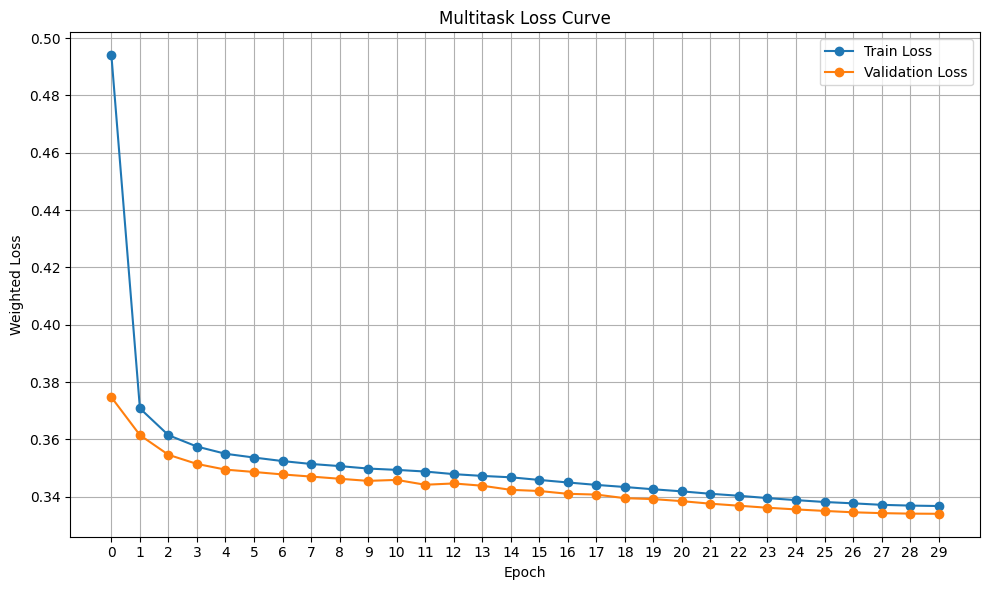

In [64]:
# Plot train loss vs val loss for multitask_large
plt.figure(figsize=(10, 6))
plt.plot(multi_large['epoch'], multi_large['train_loss'], label='Train Loss', marker='o')
plt.plot(multi_large['epoch'], multi_large['val_loss'], label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.xticks(range(30))
plt.ylabel('Weighted Loss')
plt.title('Multitask Loss Curve')
plt.legend()
plt.grid(visible=True)
plt.tight_layout()

plt.show()

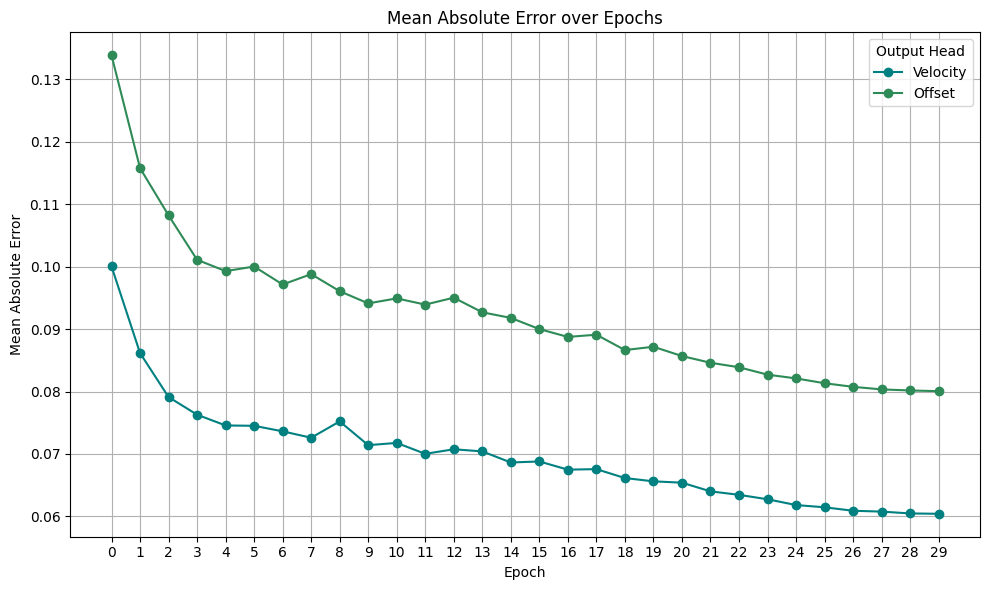

In [65]:
# plot mean absolute error for velocity and offset over epochs
plt.figure(figsize=(10, 6))
plt.plot(multi_large['epoch'], multi_large['velocity/mae'], label='Velocity', marker='o', color='teal')
plt.plot(multi_large['epoch'], multi_large['offset/mae'], label='Offset', marker='o', color='seagreen')
plt.xlabel('Epoch')
plt.xticks(range(30))
plt.ylabel('Mean Absolute Error')
plt.title('Mean Absolute Error over Epochs')
plt.legend(title="Output Head")
plt.grid(visible=True)
plt.tight_layout()
plt.show()

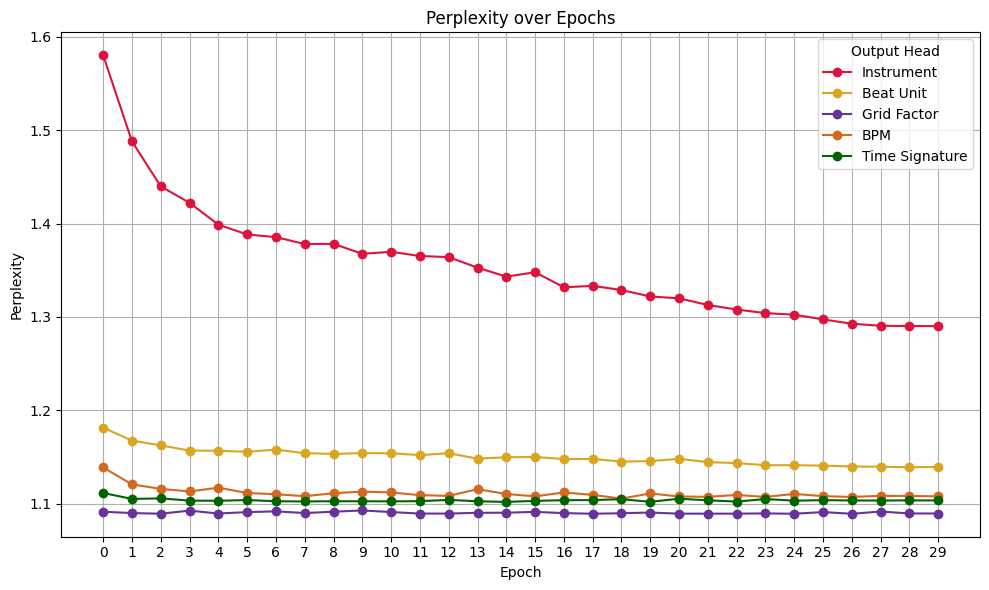

In [66]:
# perplexity over epochs

plt.figure(figsize=(10, 6))
plt.plot(multi_large['epoch'], multi_large['instrument/perplexity'], label='Instrument', marker='o', color='crimson')
plt.plot(multi_large['epoch'], multi_large['beat_unit/perplexity'], label='Beat Unit', marker='o', color='goldenrod')
plt.plot(multi_large['epoch'], multi_large['grid_factor/perplexity'], label='Grid Factor', marker='o', color='rebeccapurple')
plt.plot(multi_large['epoch'], multi_large['bpm/perplexity'], label='BPM', marker='o', color='chocolate')
plt.plot(multi_large['epoch'], multi_large['time_signature/perplexity'], label='Time Signature', marker='o', color='darkgreen')
plt.xlabel('Epoch')
plt.xticks(range(30))
plt.ylabel('Perplexity')
plt.title('Perplexity over Epochs')
plt.legend(title="Output Head")
plt.grid(visible=True)
plt.tight_layout()
plt.show()

In [67]:
seq_large = df[df['model'] == 'sequential_large']
seq_large

,epoch,global_step,start_time,end_time,elapsed_sec,train_loss,val_loss,monitor,mode,vram_peak_mb,...,offset/accuracy,offset/top_k_accuracy@3,offset/perplexity,loss_log_vars.beat_unit,loss_log_vars.bpm,loss_log_vars.grid_factor,loss_log_vars.instrument,loss_log_vars.offset,loss_log_vars.time_signature,loss_log_vars.velocity
465,0,15310,2025-11-22 14:25:54,2025-11-22 17:23:31,10656.73,2.104126,1.804573,val_loss,min,23583.16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
466,1,30620,2025-11-22 17:23:32,2025-11-22 20:20:29,10616.78,1.778938,1.709489,val_loss,min,23583.19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
467,2,45930,2025-11-22 20:20:30,2025-11-22 23:17:26,10615.62,1.716959,1.664851,val_loss,min,23583.19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
468,3,61240,2025-11-22 23:17:27,2025-11-23 02:14:39,10631.79,1.689587,1.659789,val_loss,min,23583.19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
469,4,76550,2025-11-23 02:14:40,2025-11-23 05:11:54,10633.74,1.672958,1.628331,val_loss,min,23583.19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
470,5,91860,2025-11-23 05:11:55,2025-11-23 08:09:10,10634.71,1.661444,1.613904,val_loss,min,23583.19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
471,6,107170,2025-11-23 08:09:11,2025-11-23 11:06:53,10661.99,1.651982,1.604592,val_loss,min,23583.19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
472,7,122480,2025-11-23 11:06:55,2025-11-23 14:04:27,10652.12,1.644453,1.597644,val_loss,min,23583.19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
473,8,137790,2025-11-23 14:04:28,2025-11-23 17:01:57,10649.07,1.637015,1.590210,val_loss,min,23583.19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
474,9,153100,2025-11-23 17:01:58,2025-11-23 19:59:29,10651.06,1.631398,1.584847,val_loss,min,23583.16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


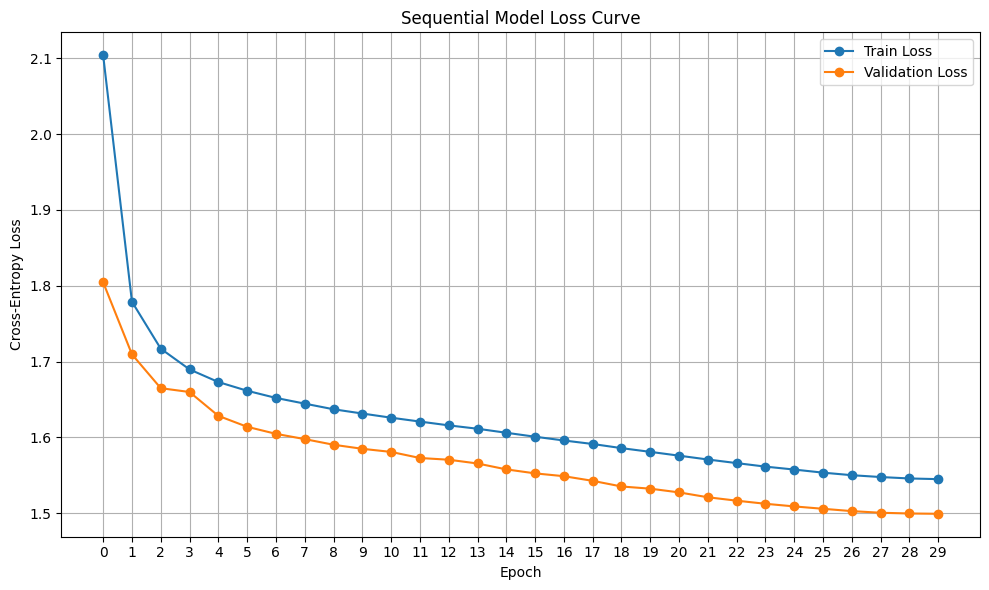

In [68]:
# plot loss curves for sequential_large
plt.figure(figsize=(10, 6))
plt.plot(seq_large['epoch'], seq_large['train_loss'], label='Train Loss', marker='o')
plt.plot(seq_large['epoch'], seq_large['val_loss'], label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.xticks(range(30))
plt.ylabel('Cross-Entropy Loss')
plt.title('Sequential Model Loss Curve')
plt.legend()
plt.grid(visible=True)
plt.tight_layout()
plt.show()

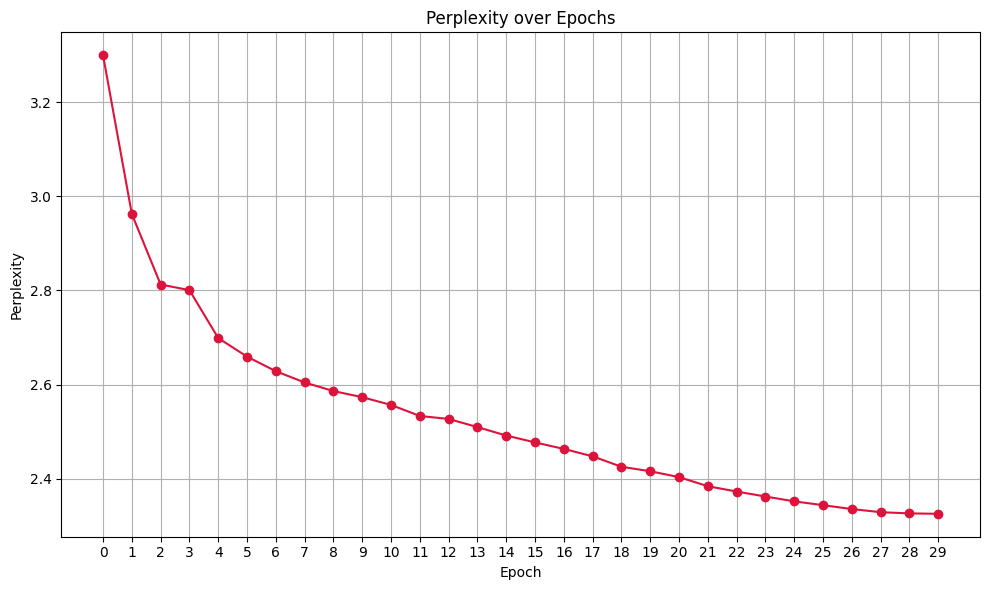

In [69]:
# plot perplexity over epochs for sequential_large
plt.figure(figsize=(10, 6))
plt.plot(seq_large['epoch'], seq_large['perplexity'], label='Perplexity', marker='o', color='crimson')
plt.xlabel('Epoch')
plt.xticks(range(30))
plt.ylabel('Perplexity')
plt.title('Perplexity over Epochs')
plt.grid(visible=True)
plt.tight_layout()
plt.show()

In [70]:
df_finetuned_seq =df[df['model'] == 'finetuned_sequential_large']

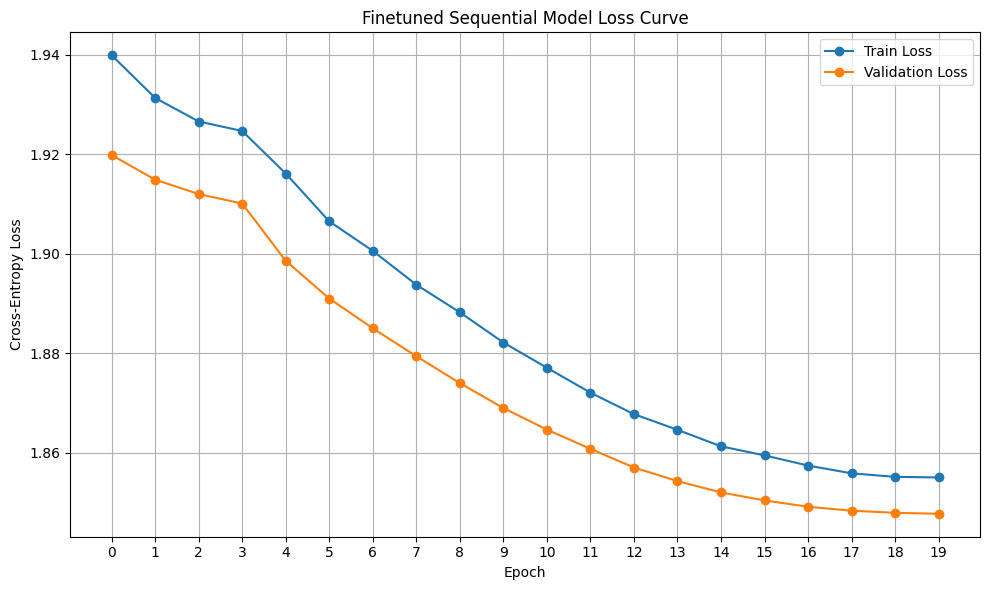

In [71]:
# plot loss curves for finetuned_sequential_large
plt.figure(figsize=(10, 6))
plt.plot(df_finetuned_seq['epoch'], df_finetuned_seq['train_loss'], label='Train Loss', color="tab:blue", marker='o')
plt.plot(df_finetuned_seq['epoch'], df_finetuned_seq['val_loss'], label='Validation Loss', color="tab:orange", marker='o')
plt.xlabel('Epoch')
plt.xticks(range(20))
plt.ylabel('Cross-Entropy Loss')
plt.title('Finetuned Sequential Model Loss Curve')
plt.legend()
plt.grid(visible=True)
plt.tight_layout()
plt.savefig("finetuned_sequential_large_loss_curve.png",
            format="png",
            transparent=True,
            dpi=300,
            bbox_inches="tight")
plt.show()

In [72]:
df_mt_ft = df[df['model'] == 'finetuned_multitask_large']

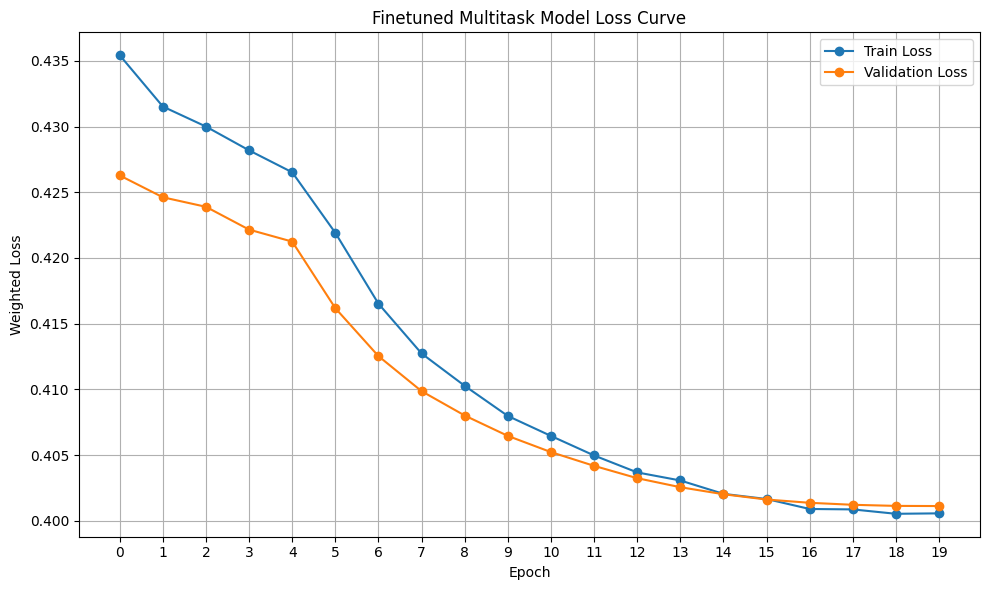

In [73]:
# plot loss curves for finetuned_multitask_large
plt.figure(figsize=(10, 6))
plt.plot(df_mt_ft['epoch'], df_mt_ft['train_loss'], label='Train Loss', marker='o')
plt.plot(df_mt_ft['epoch'], df_mt_ft['val_loss'], label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.xticks(range(20))
plt.ylabel('Weighted Loss')
plt.title('Finetuned Multitask Model Loss Curve')
plt.legend()
plt.grid(visible=True)
plt.tight_layout()
plt.savefig("finetuned_multitask_large_loss_curve.png",
            format="png",
            dpi=300,
            bbox_inches="tight")
plt.show()

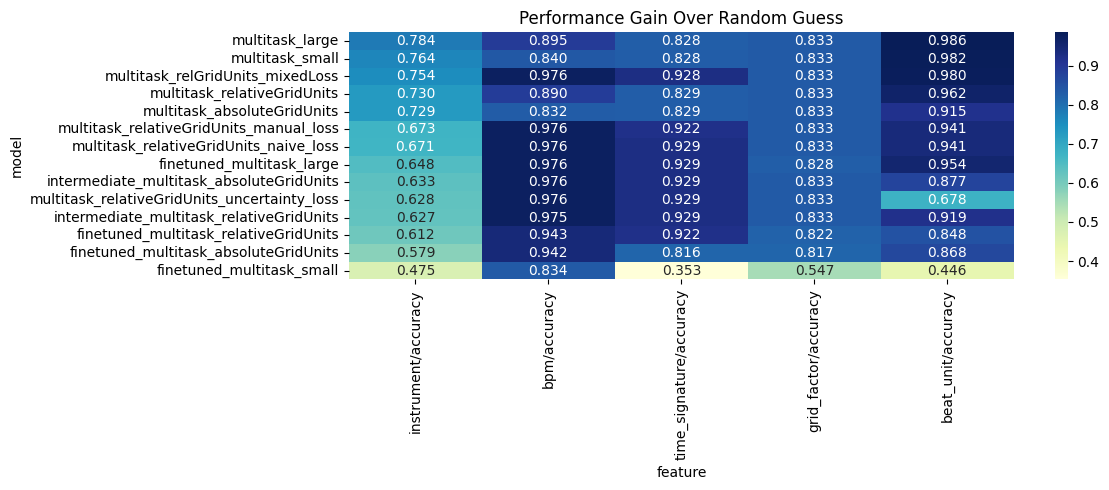

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Copy accuracy subset
acc = df_multi.set_index("model")[
    [
        "instrument/accuracy",
        "bpm/accuracy",
        "time_signature/accuracy",
        "grid_factor/accuracy",
        "beat_unit/accuracy",
    ]
]

# compute random baseline per model for beat_unit
rand = acc.copy()
for m in rand.index:
    rand.loc[m, "beat_unit/accuracy"] = (
        random_lines["rel_beat_unit/accuracy"]
        if "relative" in m
        else random_lines["abs_beat_unit/accuracy"]
    )

# fill the other columns from single baseline dict
for c in rand.columns:
    if c != "beat_unit/accuracy":
        rand[c] = random_lines[c]

gain = acc - rand  # improvement over random

plt.figure(figsize=(12, 5))
sns.heatmap(gain, annot=True, fmt=".3f", cmap="YlGnBu", cbar=True)
plt.title("Performance Gain Over Random Guess")
plt.ylabel("model")
plt.xlabel("feature")
plt.tight_layout()
plt.show()

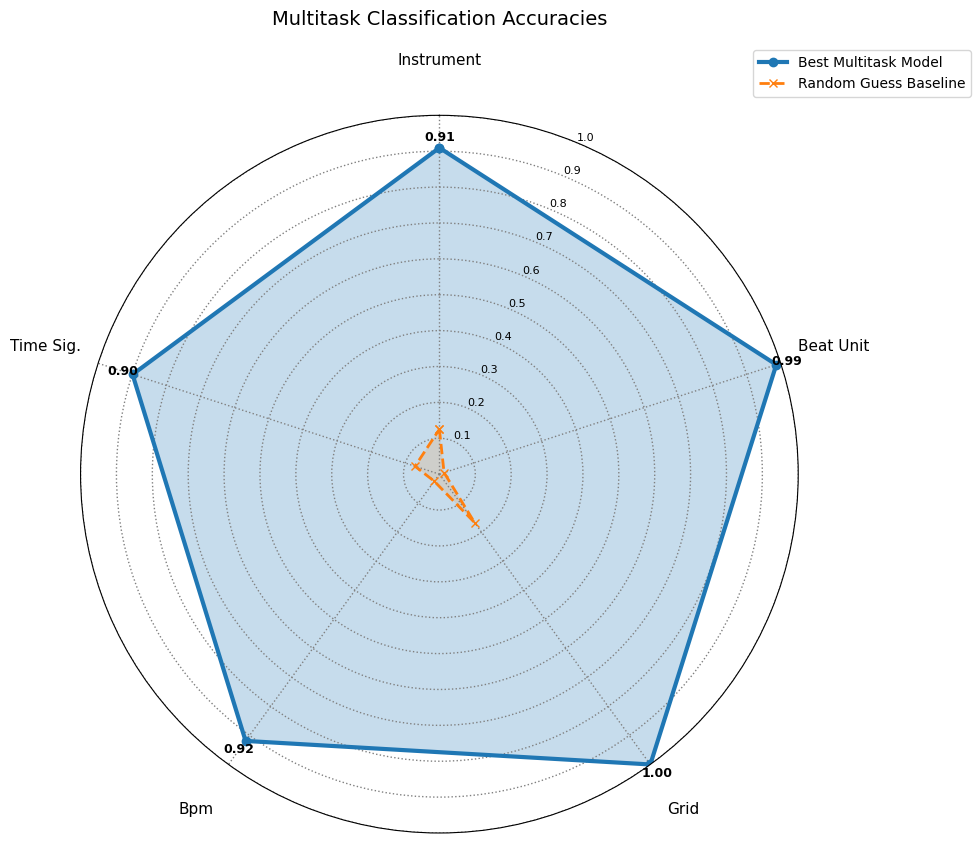

In [80]:
import numpy as np
import matplotlib.pyplot as plt

model_name = "multitask_large"

# Select row
row = df_multi[df_multi["model"] == model_name].iloc[0]

# Accuracy columns that have random baselines
acc_cols = [c for c in df_multi.columns if c.endswith("/accuracy")]
acc_cols = [
    c for c in acc_cols
    if (c in random_lines) or (c == "beat_unit/accuracy")
]

# Data collection
acc_values = []
baseline_values = []
labels = []

for col in acc_cols:
    acc_values.append(row[col])

    if col == "beat_unit/accuracy":
        if "relative" or "large" in model_name.lower():
            baseline = random_lines["rel_beat_unit/accuracy"]
        else:
            baseline = random_lines["abs_beat_unit/accuracy"]
    else:
        baseline = random_lines[col]

    baseline_values.append(baseline)

    # nicer label text
    name = col.split("/")[0]
    replacements = {
        "time_signature": "Time Sig.",
        "grid_factor": "Grid",
        "beat_unit": "Beat Unit",
        "instrument": "Instrument",
    }
    name = replacements.get(name, name.capitalize())
    labels.append(name)

acc_values = np.array(acc_values)
baseline_values = np.array(baseline_values)

# Close polygons
acc = np.append(acc_values, acc_values[0])
rand = np.append(baseline_values, baseline_values[0])

N = len(acc_cols)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10,10), subplot_kw=dict(polar=True))

# Rotation: put first axis at the top
ax.set_theta_offset(np.pi/2)
ax.set_theta_direction(-1)

# Plot main model
ax.plot(angles, acc, linewidth=3, marker="o", label="Best Multitask Model")
ax.fill(angles, acc, alpha=0.25)

# Plot baseline
ax.plot(angles, rand, linewidth=2, linestyle="--", marker="x", label="Random Guess Baseline")
ax.fill(angles, rand, alpha=0.15)

# Feature labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
# Move feature labels slightly further out
for label, angle in zip(ax.get_xticklabels(), angles[:-1]):
    label.set_horizontalalignment('center')
    label.set_verticalalignment('center')
    label.set_position((angle, -0.1))  # 1.10 pushes labels outward


# Visible grid
ax.set_ylim(0, 1)
ax.set_yticks(np.linspace(0.1, 1.0, 10))
ax.set_yticklabels([f"{x:.1f}" for x in np.linspace(0.1, 1.0, 10)], fontsize=8)
ax.grid(color="gray", linestyle=":", linewidth=1)

# Annotate value labels
for angle, value in zip(angles[:-1], acc_values):
    ax.text(angle, value + 0.03, f"{value:.2f}",
            ha="center", va="center", fontsize=9, fontweight="bold")

# Title + legend
ax.set_title(f"Multitask Classification Accuracies", fontsize=14, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))

plt.tight_layout()

plt.savefig("radar_multitask_large.png",
            format="png",
            dpi=1000,
            bbox_inches="tight",
            transparent=True)
plt.show()


In [76]:
# find all feature perplexity columns
ppl_cols = [
    c for c in df_multi.columns
    if c.lower().endswith("/perplexity")
]

# build sorted table
ppl_table = (
    df_multi
    .set_index("model")[ppl_cols]
    .sort_index()   # or sort by mean perplexity
    .round(3)
)

ppl_table


,instrument/perplexity,beat_unit/perplexity,grid_factor/perplexity,bpm/perplexity,time_signature/perplexity,velocity/perplexity,offset/perplexity
model,,,,,,,
finetuned_multitask_absoluteGridUnits,1.842,1.271,1.097,1.119,1.105,NaN,NaN
finetuned_multitask_large,1.747,1.230,1.096,1.108,1.103,NaN,NaN
finetuned_multitask_relativeGridUnits,1.827,1.247,1.093,1.120,1.104,NaN,NaN
finetuned_multitask_small,1.966,1.271,1.126,1.258,1.144,NaN,NaN
intermediate_multitask_absoluteGridUnits,1.864,1.299,1.089,1.110,1.102,NaN,NaN
intermediate_multitask_relativeGridUnits,1.896,1.239,1.090,1.120,1.103,NaN,NaN
multitask_absoluteGridUnits,1.500,1.210,1.091,1.108,1.105,NaN,NaN
multitask_large,1.290,1.139,1.090,1.108,1.104,NaN,NaN
multitask_relGridUnits_mixedLoss,1.292,1.065,1.000,1.000,1.000,NaN,NaN


In [77]:
# auto-detect metrics
mae_cols = [c for c in df_multi.columns if c.lower().endswith("/mae")]
mse_cols = [c for c in df_multi.columns if c.lower().endswith("/mse")]

# keep same ordering for features (pairs stay together)
features = sorted(set(c.split("/")[0] for c in mae_cols + mse_cols))

# build MultiIndex table: first level is metric, second is feature
combined = {}
for metric, cols in [("MAE", mae_cols), ("MSE", mse_cols)]:
    # reorder columns to match feature list
    ordered_cols = [
        f"{feat}/{metric.lower()}"
        for feat in features
        if f"{feat}/{metric.lower()}" in cols
    ]
    combined[metric] = df_multi.set_index("model")[ordered_cols]

error_table = (
    pd.concat(combined, axis=1)
    .round(4)  # nice rounding
    .sort_index()  # alphabetical model order (or change to sort by mean error)
)

error_table

MAE               \
                                             offset/mae velocity/mae   
model                                                                  
finetuned_multitask_absoluteGridUnits            0.1314       0.1073   
finetuned_multitask_large                        0.1271       0.1025   
finetuned_multitask_relativeGridUnits            0.1296       0.1050   
finetuned_multitask_small                        0.1964       0.1434   
intermediate_multitask_absoluteGridUnits         0.2315       0.1340   
intermediate_multitask_relativeGridUnits         0.2327       0.1335   
multitask_absoluteGridUnits                      0.1003       0.0708   
multitask_large                                  0.0801       0.0604   
multitask_relGridUnits_mixedLoss                 0.1079       0.0771   
multitask_relativeGridUnits                      0.0985       0.0692   
multitask_relativeGridUnits_manual_loss          0.1239       0.0984   
multitask_relativeGridUnits_naive_loss           0.1293       0.1016   
multitask_relativeGridUnits_uncertainty_loss     0.1191       0.0958   
multitask_small                                  0.0910       0.0700   

                                                    MSE               
                                             offset/mse velocity/mse  
model                                                                 
finetuned_multitask_absoluteGridUnits            0.0862       0.0488  
finetuned_multitask_large                        0.0823       0.0461  
finetuned_multitask_relativeGridUnits            0.0840       0.0477  
finetuned_multitask_small                        0.0970       0.0619  
intermediate_multitask_absoluteGridUnits         0.1681       0.0531  
intermediate_multitask_relativeGridUnits         0.1680       0.0533  
multitask_absoluteGridUnits                      0.0676       0.0269  
multitask_large                                  0.0387       0.0179  
multitask_relGridUnits_mixedLoss                 0.0660       0.0259  
multitask_relativeGridUnits                      0.0660       0.0262  
multitask_relativeGridUnits_manual_loss          0.0788       0.0435  
multitask_relativeGridUnits_naive_loss           0.0806       0.0445  
multitask_relativeGridUnits_uncertainty_loss     0.0809       0.0451  
multitask_small                                  0.0481       0.0226

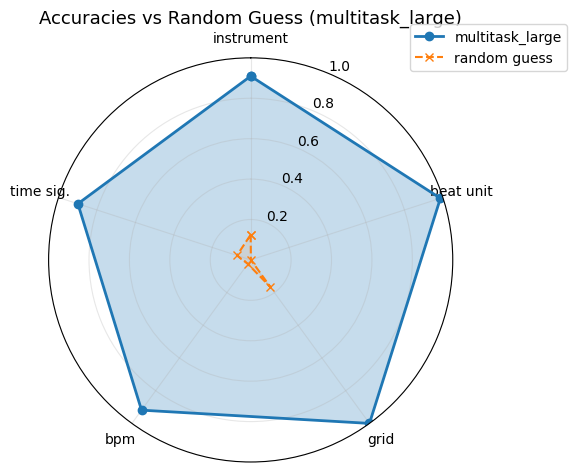

In [78]:
import numpy as np
import matplotlib.pyplot as plt

model_name = "multitask_large"

# 1) Select row for the model
row = df_multi[df_multi["model"] == model_name].iloc[0]

# 2) Choose which accuracy features to include (must also have random baselines)
acc_cols = [c for c in df_multi.columns if c.endswith("/accuracy")]
acc_cols = [
    c for c in acc_cols
    if (c in random_lines) or (c == "beat_unit/accuracy")
]

# 3) Build arrays for model accuracies and random baselines
acc_values = []
baseline_values = []
labels = []

for col in acc_cols:
    acc_values.append(row[col])

    if col == "beat_unit/accuracy":
        # absolute vs relative beat-unit baseline (this model is absolute)
        if "relative" in model_name.lower():
            baseline = random_lines["rel_beat_unit/accuracy"]
        else:
            baseline = random_lines["abs_beat_unit/accuracy"]
    else:
        baseline = random_lines[col]

    baseline_values.append(baseline)

    # shorter labels for the plot
    lbl = col.split("/")[0]
    if lbl == "time_signature":
        lbl = "time sig."
    elif lbl == "grid_factor":
        lbl = "grid"
    elif lbl == "beat_unit":
        lbl = "beat unit"
    labels.append(lbl)

acc_values = np.array(acc_values)
baseline_values = np.array(baseline_values)

# close the polygons (repeat first element at the end)
acc_values = np.append(acc_values, acc_values[0])
baseline_values = np.append(baseline_values, baseline_values[0])

# 4) Radar geometry
N = len(acc_cols)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

# Put 0° at top and go clockwise
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# 5) Plot model and random baseline
ax.plot(angles, acc_values, linewidth=2, marker="o", label=model_name)
ax.fill(angles, acc_values, alpha=0.25)

ax.plot(angles, baseline_values, linewidth=1.5, linestyle="--", marker="x",
        label="random guess")
ax.fill(angles, baseline_values, alpha=0.1)

# 6) Formatting: labels and fixed radius [0, 1]
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10)

ax.set_ylim(0.0, 1.0)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"])
ax.grid(alpha=0.3)

ax.set_title(f"Accuracies vs Random Guess ({model_name})", fontsize=13)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()
